In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the downloaded NetCDF file
dataset = xr.open_dataset("../Data/cmems_mod_glo_phy_my_0.083deg_P1D-m_1791433952806.nc")

# Display the dataset
dataset

<xarray.Dataset> Size: 412MB
Dimensions:    (time: 7, depth: 50, latitude: 253, longitude: 288)
Coordinates:
  * time       (time) datetime64[ns] 56B 2017-10-01 2017-10-02 ... 2017-10-07
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 1kB -52.0 -51.92 -51.83 ... -31.08 -31.0
  * longitude  (longitude) float32 1kB 161.0 161.1 161.2 ... 184.8 184.8 184.9
Data variables:
    so         (time, depth, latitude, longitude) float32 102MB ...
    thetao     (time, depth, latitude, longitude) float32 102MB ...
    uo         (time, depth, latitude, longitude) float32 102MB ...
    vo         (time, depth, latitude, longitude) float32 102MB ...
    zos        (time, latitude, longitude) float32 2MB ...
    bottomT    (time, latitude, longitude) float32 2MB ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       MERCATOR OCEAN
    source:            MERCATOR GLORYS12V1
    history:           2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    references:        http://www.mercator-ocean.fr
    comment:           CMEMS product
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1D-m_202311
    subset:date:       2026-10-08T04:32:32.807Z

In [2]:
print(list(dataset.data_vars))

['so', 'thetao', 'uo', 'vo', 'zos', 'bottomT']


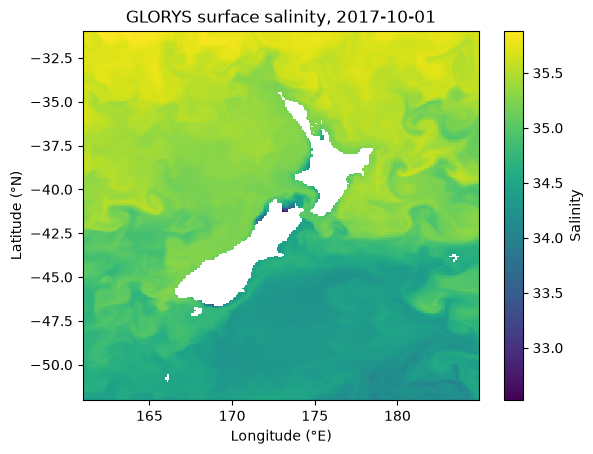

In [3]:
# --- Salinity Plot ---
so = dataset["so"].isel(time=0, depth=0)
so.plot(cmap="viridis", cbar_kwargs={"label": "Salinity"})
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"GLORYS surface salinity, {str(so.time.values)[:10]}")
plt.savefig(f"../Figures/glorys_salt_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

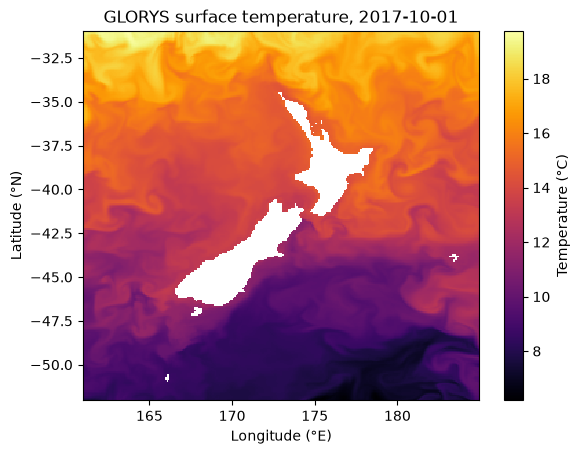

In [4]:
# --- Temperature Plot ---
thetao = dataset["thetao"].isel(time=0, depth=0)
thetao.plot(cmap="inferno", cbar_kwargs={"label": "Temperature (°C)"})
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"GLORYS surface temperature, {str(thetao.time.values)[:10]}")
plt.savefig(f"../Figures/glorys_sst_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

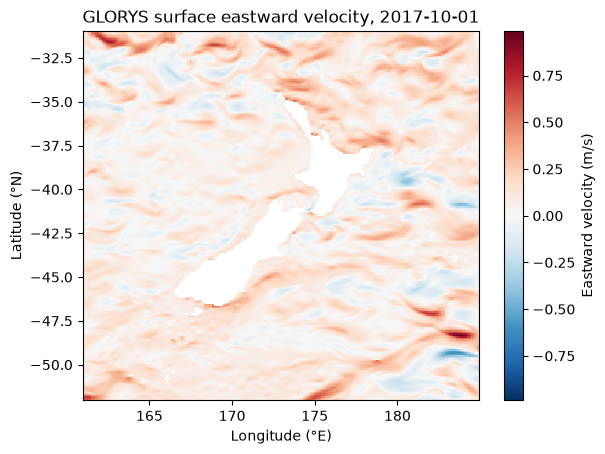

In [5]:
# --- East-West (U) Velocity Plot ---
uo = dataset["uo"].isel(time=0, depth=0)
uo.plot(cmap="RdBu_r", cbar_kwargs={"label": "Eastward velocity (m/s)"})
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"GLORYS surface eastward velocity, {str(uo.time.values)[:10]}")
plt.savefig(f"../Figures/glorys_u_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

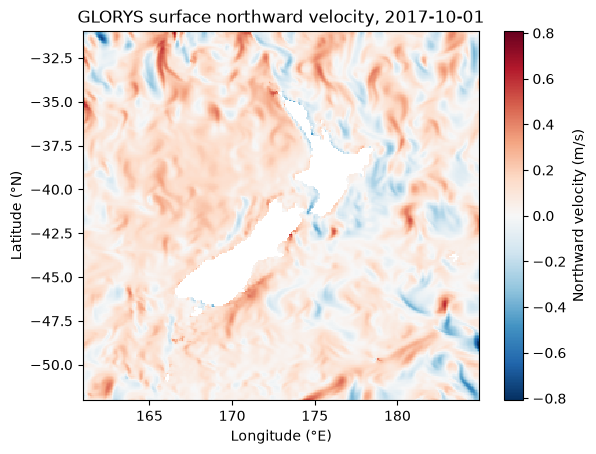

In [6]:
# --- North-South (V) Velocity Plot ---
vo = dataset["vo"].isel(time=0, depth=0)
vo.plot(cmap="RdBu_r", cbar_kwargs={"label": "Northward velocity (m/s)"})
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"GLORYS surface northward velocity, {str(vo.time.values)[:10]}")
plt.savefig(f"../Figures/glorys_v_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

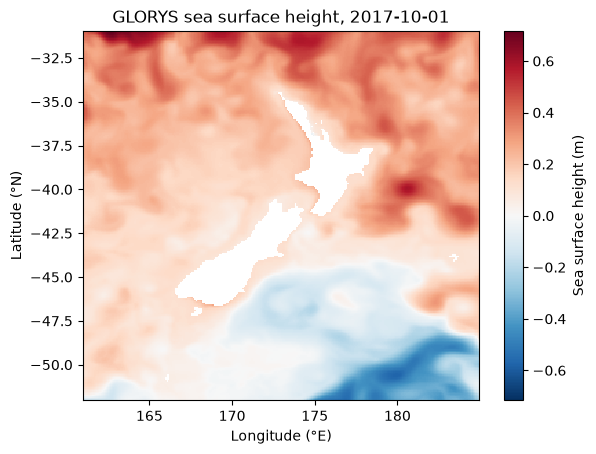

In [7]:
# --- Sea Surface Height Plot ---
zos = dataset["zos"].isel(time=0)
zos.plot(cmap="RdBu_r", cbar_kwargs={"label": "Sea surface height (m)"})
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"GLORYS sea surface height, {str(zos.time.values)[:10]}")
plt.savefig(f"../Figures/glorys_ssh_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

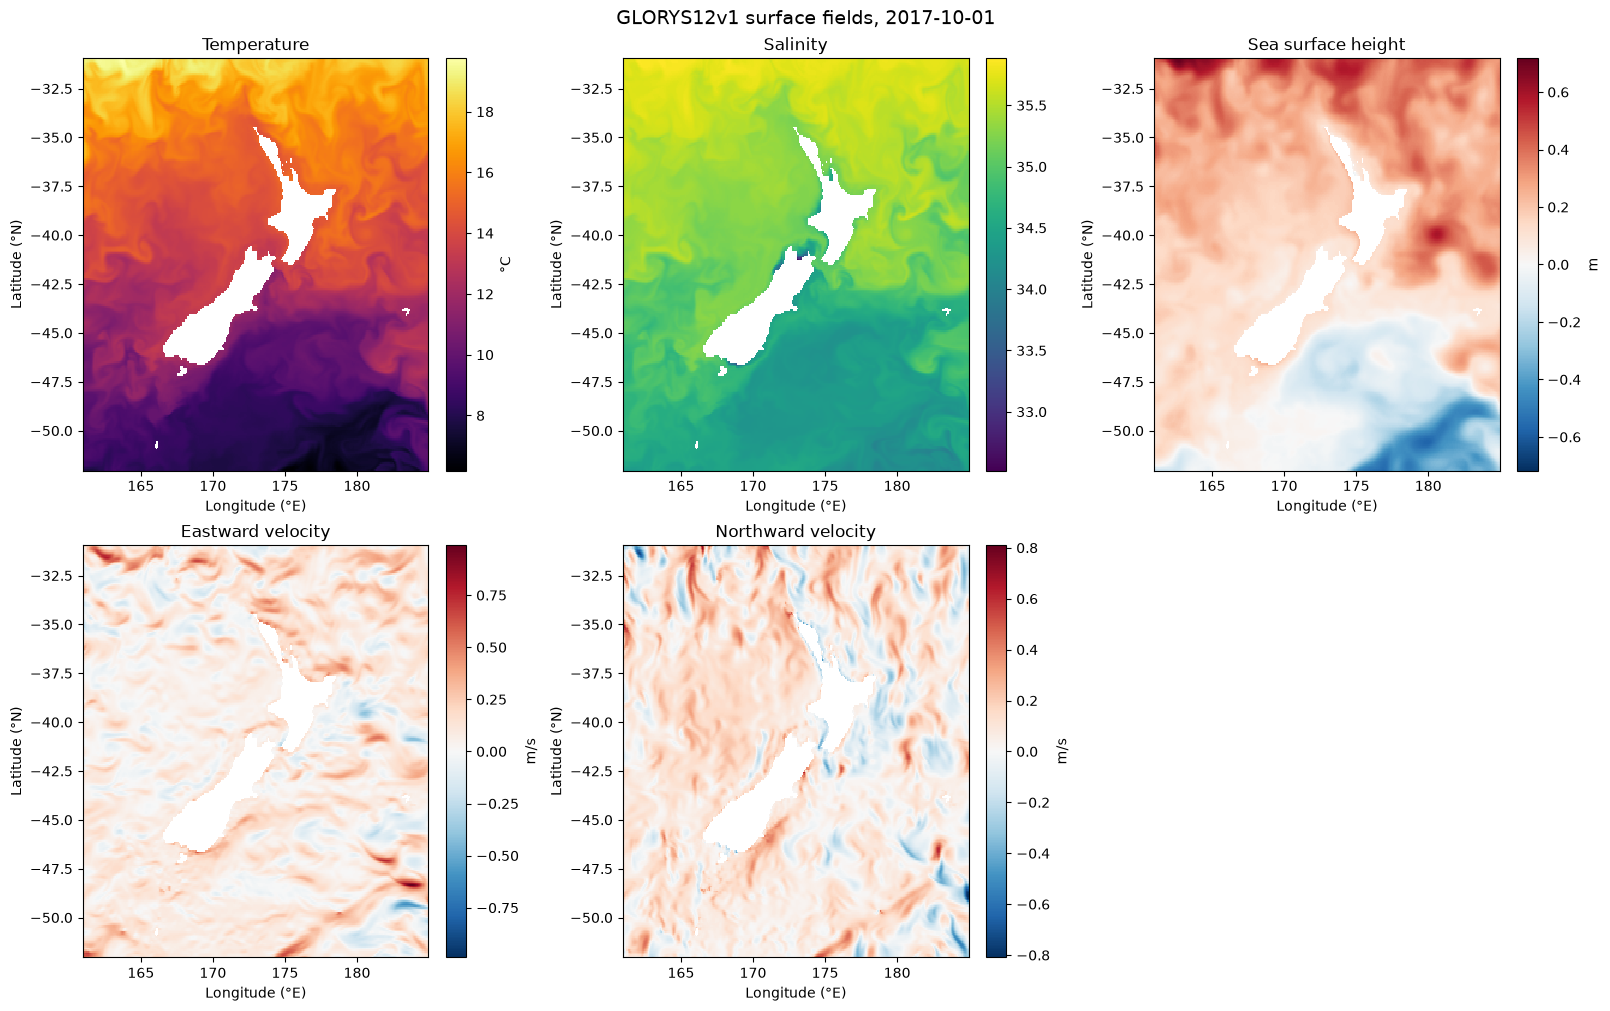

In [ ]:
# --- Plot all 5 variables ---
s = dataset.isel(time=0, depth=0)      # first time, surface (zos has no depth, so it's left alone)
date = str(s.time.values)[:10]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

s["thetao"].plot(ax=axes[0, 0], cmap="inferno", cbar_kwargs={"label": "°C"})
s["so"].plot(    ax=axes[0, 1], cmap="viridis", cbar_kwargs={"label": ""})
s["zos"].plot(   ax=axes[0, 2], cmap="RdBu_r", cbar_kwargs={"label": "m"})
s["uo"].plot(    ax=axes[1, 0], cmap="RdBu_r", cbar_kwargs={"label": "m/s"})
s["vo"].plot(    ax=axes[1, 1], cmap="RdBu_r", cbar_kwargs={"label": "m/s"})

axes[0, 0].set_title("Temperature")
axes[0, 1].set_title("Salinity")
axes[0, 2].set_title("Sea surface height")
axes[1, 0].set_title("Eastward velocity")
axes[1, 1].set_title("Northward velocity")
axes[1, 2].set_visible(False)          # empty 6th panel

for ax in axes.flat:
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

fig.suptitle(f"GLORYS12v1 surface fields, {date}", fontsize=14)
plt.savefig(f"../Figures/glorys_surface_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Checking grid of ROMS and GLORYS to compare
grd = xr.open_dataset("/projects/f_omg_1/moa/moana/grd_moana5km.nc")     # your grid file path

print("ROMS grid")
print("  lon:", grd.lon_rho.min().item(), "to", grd.lon_rho.max().item())
print("  lat:", grd.lat_rho.min().item(), "to", grd.lat_rho.max().item())
print("  max depth:", grd.h.max().item())

print("GLORYS")
print("  lon:", dataset.longitude.min().item(), "to", dataset.longitude.max().item())
print("  lat:", dataset.latitude.min().item(), "to", dataset.latitude.max().item())
print("  max depth:", dataset.depth.max().item())
print("  times:", dataset.time.values[0], "to", dataset.time.values[-1])

ROMS grid
  lon: 161.0302267002461 to 184.96977329975525
  lat: -51.98124079061991 to -31.02610884707851
  max depth: 6000.0
GLORYS
  lon: 161.00001525878906 to 184.9166717529297
  lat: -52.0 to -31.0
  max depth: 5727.9169921875
  times: 2017-10-01T00:00:00.000000000 to 2017-10-07T00:00:00.000000000


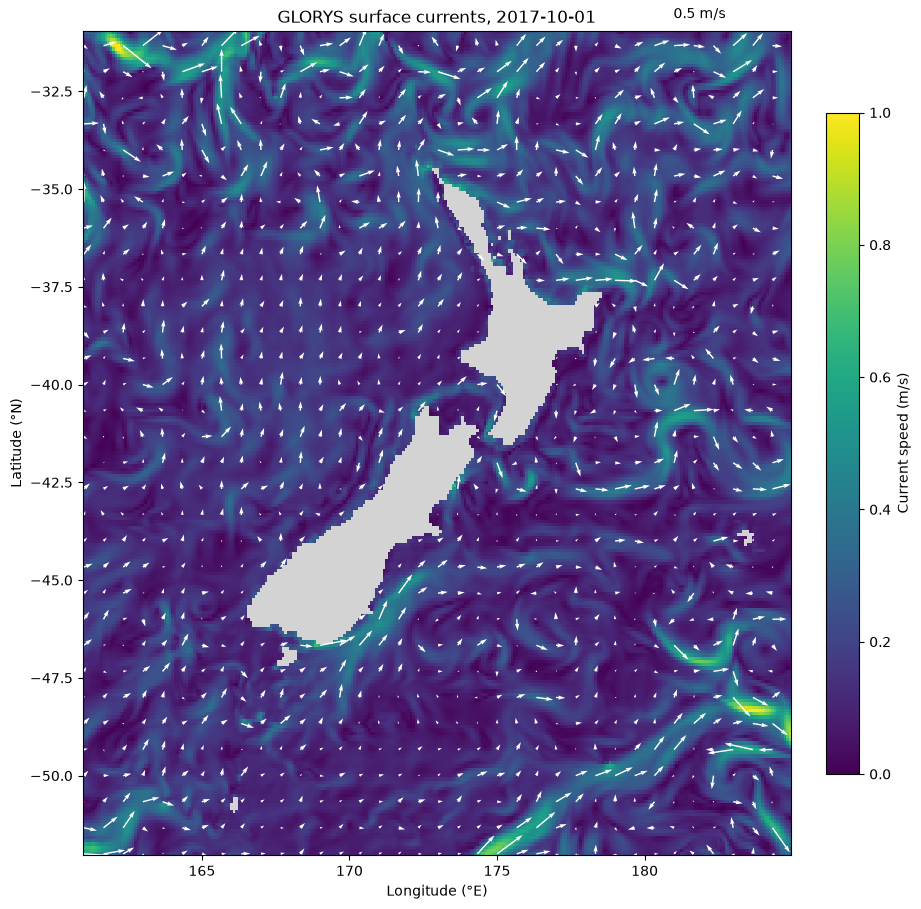

In [ ]:
import numpy as np

# --- Plot currents ---
s = dataset.isel(time=0, depth=0)            # first time, surface
lon = s.longitude.values
lat = s.latitude.values
u = s["uo"].values
v = s["vo"].values
speed = np.hypot(u, v)

n = 8                                        # arrow spacing
date = str(s.time.values)[:10]

fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)

pc = ax.pcolormesh(lon, lat, speed, cmap="viridis", vmin=0, vmax=1, shading="auto")
fig.colorbar(pc, ax=ax, shrink=0.8, label="Current speed (m/s)")

q = ax.quiver(lon[::n], lat[::n], u[::n, ::n], v[::n, ::n],
              color="white", scale=15, width=0.002)
ax.quiverkey(q, X=0.82, Y=1.02, U=0.5, label="0.5 m/s", labelpos="E")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect(1 / np.cos(np.deg2rad(41)))    # true map proportions
ax.set_facecolor("lightgrey")                # land in grey
ax.set_title(f"GLORYS surface currents, {date}")

plt.savefig(f"../Figures/glorys_currents_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

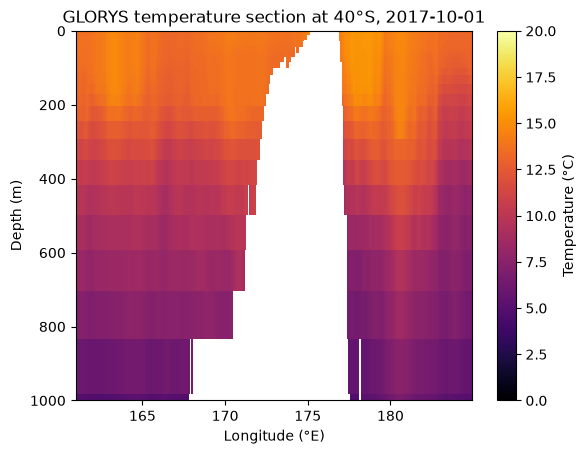

In [ ]:
# Picking a cross section to plot, looking at temperature
sec = dataset["thetao"].isel(time=0).sel(latitude=-40, method="nearest")

sec.plot(y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20,
         cbar_kwargs={"label": "Temperature (°C)"})

plt.ylim(1000, 0)                      # show the top 1000 m
plt.xlabel("Longitude (°E)")
plt.ylabel("Depth (m)")
plt.title(f"GLORYS temperature section at 40°S, {str(sec.time.values)[:10]}")
plt.savefig(f"../Figures/glorys_basic_temp_cross_section_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

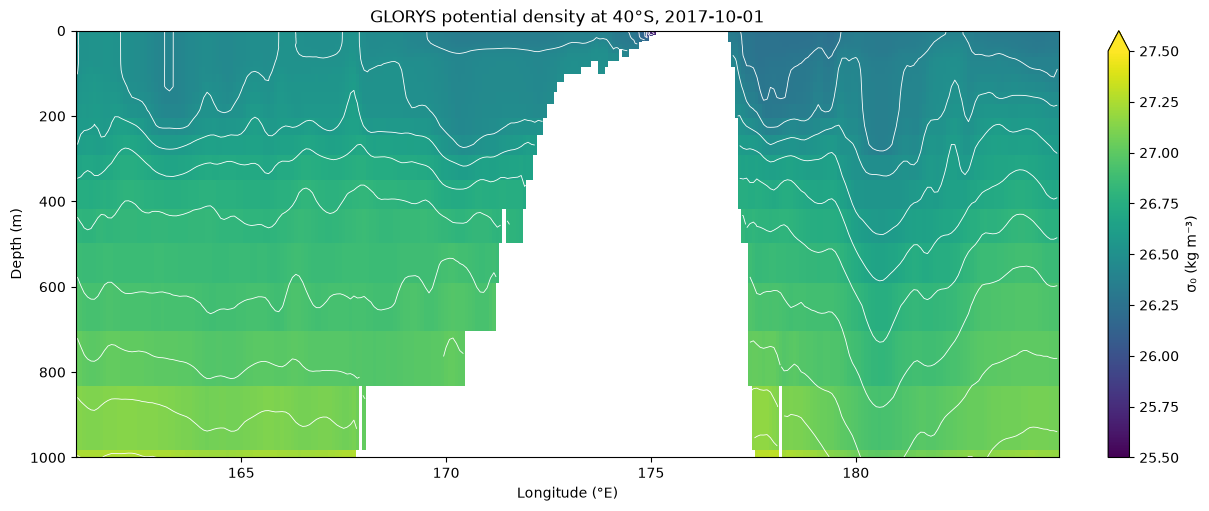

In [ ]:
import gsw

# --- Plotting potentila density cross section (40 S) ---
# 1) pick the day and the section
sec = dataset.sel(time=np.datetime64("2017-10-01"), method="nearest") \
             .sel(latitude=-40, method="nearest")
lat0 = float(sec.latitude)
depth = sec.depth.values
lon = sec.longitude.values

# 2) compute potential density (sigma0) from temperature and salinity
p  = gsw.p_from_z(-depth, lat0)[:, None]                    # pressure (dbar)
SA = gsw.SA_from_SP(sec["so"].values, p, lon[None, :], lat0)  # absolute salinity
CT = gsw.CT_from_pt(SA, sec["thetao"].values)               # conservative temperature
sigma0 = xr.DataArray(gsw.sigma0(SA, CT), coords=sec["so"].coords, dims=sec["so"].dims)

# 3) plot: colour = density, lines = density contours
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
sigma0.plot(ax=ax, y="depth", yincrease=False, cmap="viridis", vmin=25.5, vmax=27.5,
            cbar_kwargs={"label": "σ₀ (kg m⁻³)"})
sigma0.plot.contour(ax=ax, y="depth", yincrease=False, colors="white",
                    levels=np.arange(25.5, 27.6, 0.1), linewidths=0.6)

ax.set_ylim(1000, 0)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"GLORYS potential density at 40°S, {str(sec.time.values)[:10]}")
plt.savefig("../Figures/glorys_sigma0_40S_cross_section_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

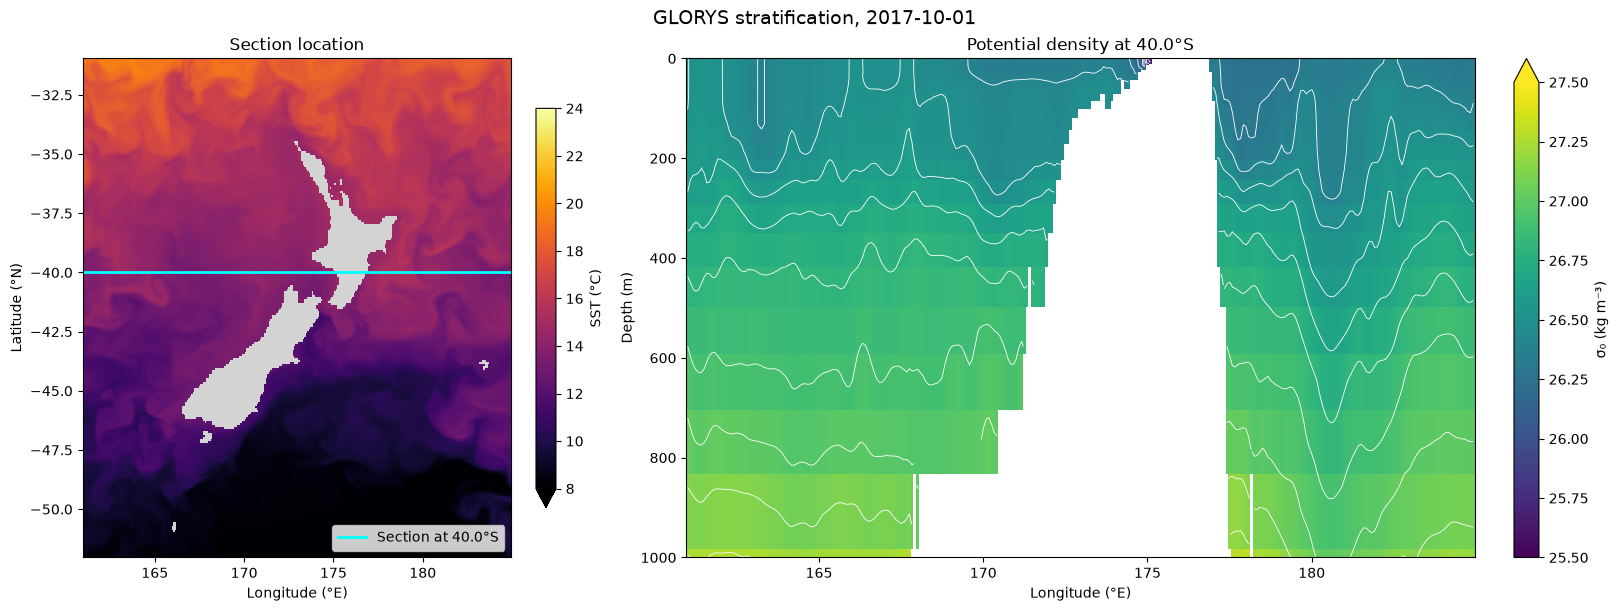

In [ ]:
# Plotting same crosss section, but with map 
day = dataset.sel(time=np.datetime64("2017-10-01"), method="nearest")
sst = day["thetao"].isel(depth=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# --- left: map with the section line ---
sst.plot(ax=ax1, cmap="inferno", vmin=8, vmax=24,
         cbar_kwargs={"label": "SST (°C)", "shrink": 0.8})
ax1.axhline(lat0, color="cyan", linewidth=2, label=f"Section at {abs(lat0):.1f}°S")
ax1.legend(loc="lower right")
ax1.set_aspect(1 / np.cos(np.deg2rad(41)))
ax1.set_facecolor("lightgrey")
ax1.set_xlabel("Longitude (°E)")
ax1.set_ylabel("Latitude (°N)")
ax1.set_title("Section location")

# --- right: the density section ---
sigma0.plot(ax=ax2, y="depth", yincrease=False, cmap="viridis", vmin=25.5, vmax=27.5,
            cbar_kwargs={"label": "σ₀ (kg m⁻³)"})
sigma0.plot.contour(ax=ax2, y="depth", yincrease=False, colors="white",
                    levels=np.arange(25.5, 27.6, 0.1), linewidths=0.6)
ax2.set_ylim(1000, 0)
ax2.set_xlabel("Longitude (°E)")
ax2.set_ylabel("Depth (m)")
ax2.set_title(f"Potential density at {abs(lat0):.1f}°S")

fig.suptitle(f"GLORYS stratification, {str(day.time.values)[:10]}", fontsize=14)
plt.savefig("../Figures/glorys_sigma0_section_map_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

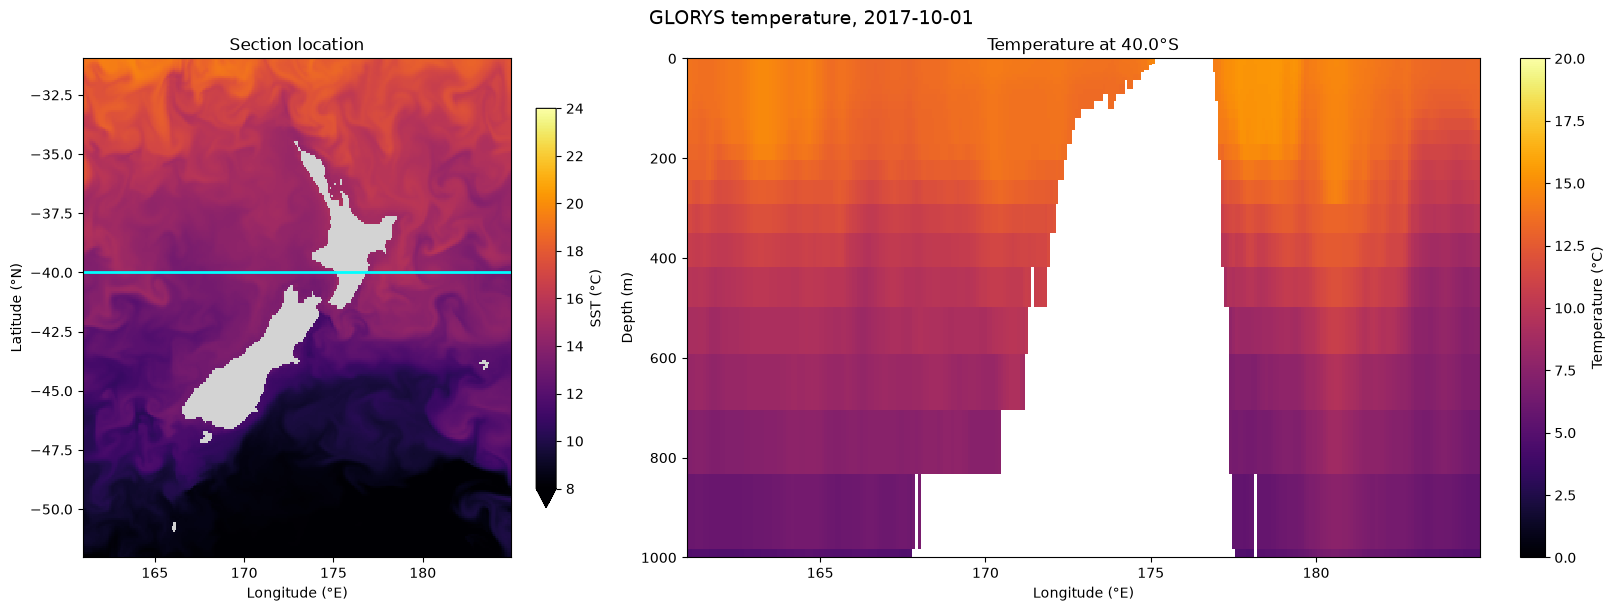

In [ ]:
# Plotting same cross section but instead of potential density, it is temperature 

sec = dataset["thetao"].isel(time=0).sel(latitude=-40, method="nearest")
sst = dataset["thetao"].isel(time=0, depth=0)
lat0 = float(sec.latitude)
date = str(sec.time.values)[:10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: map with the section line
sst.plot(ax=ax1, cmap="inferno", vmin=8, vmax=24,
         cbar_kwargs={"label": "SST (°C)", "shrink": 0.8})
ax1.axhline(lat0, color="cyan", linewidth=2)
ax1.set_aspect(1 / np.cos(np.deg2rad(41)))
ax1.set_facecolor("lightgrey")
ax1.set_xlabel("Longitude (°E)")
ax1.set_ylabel("Latitude (°N)")
ax1.set_title("Section location")

# right: your temperature section
sec.plot(ax=ax2, y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20,
         cbar_kwargs={"label": "Temperature (°C)"})
ax2.set_ylim(1000, 0)
ax2.set_xlabel("Longitude (°E)")
ax2.set_ylabel("Depth (m)")
ax2.set_title(f"Temperature at {abs(lat0):.1f}°S")

fig.suptitle(f"GLORYS temperature, {date}", fontsize=14)
plt.savefig("../Figures/glorys_temp_one_cross_section_map_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

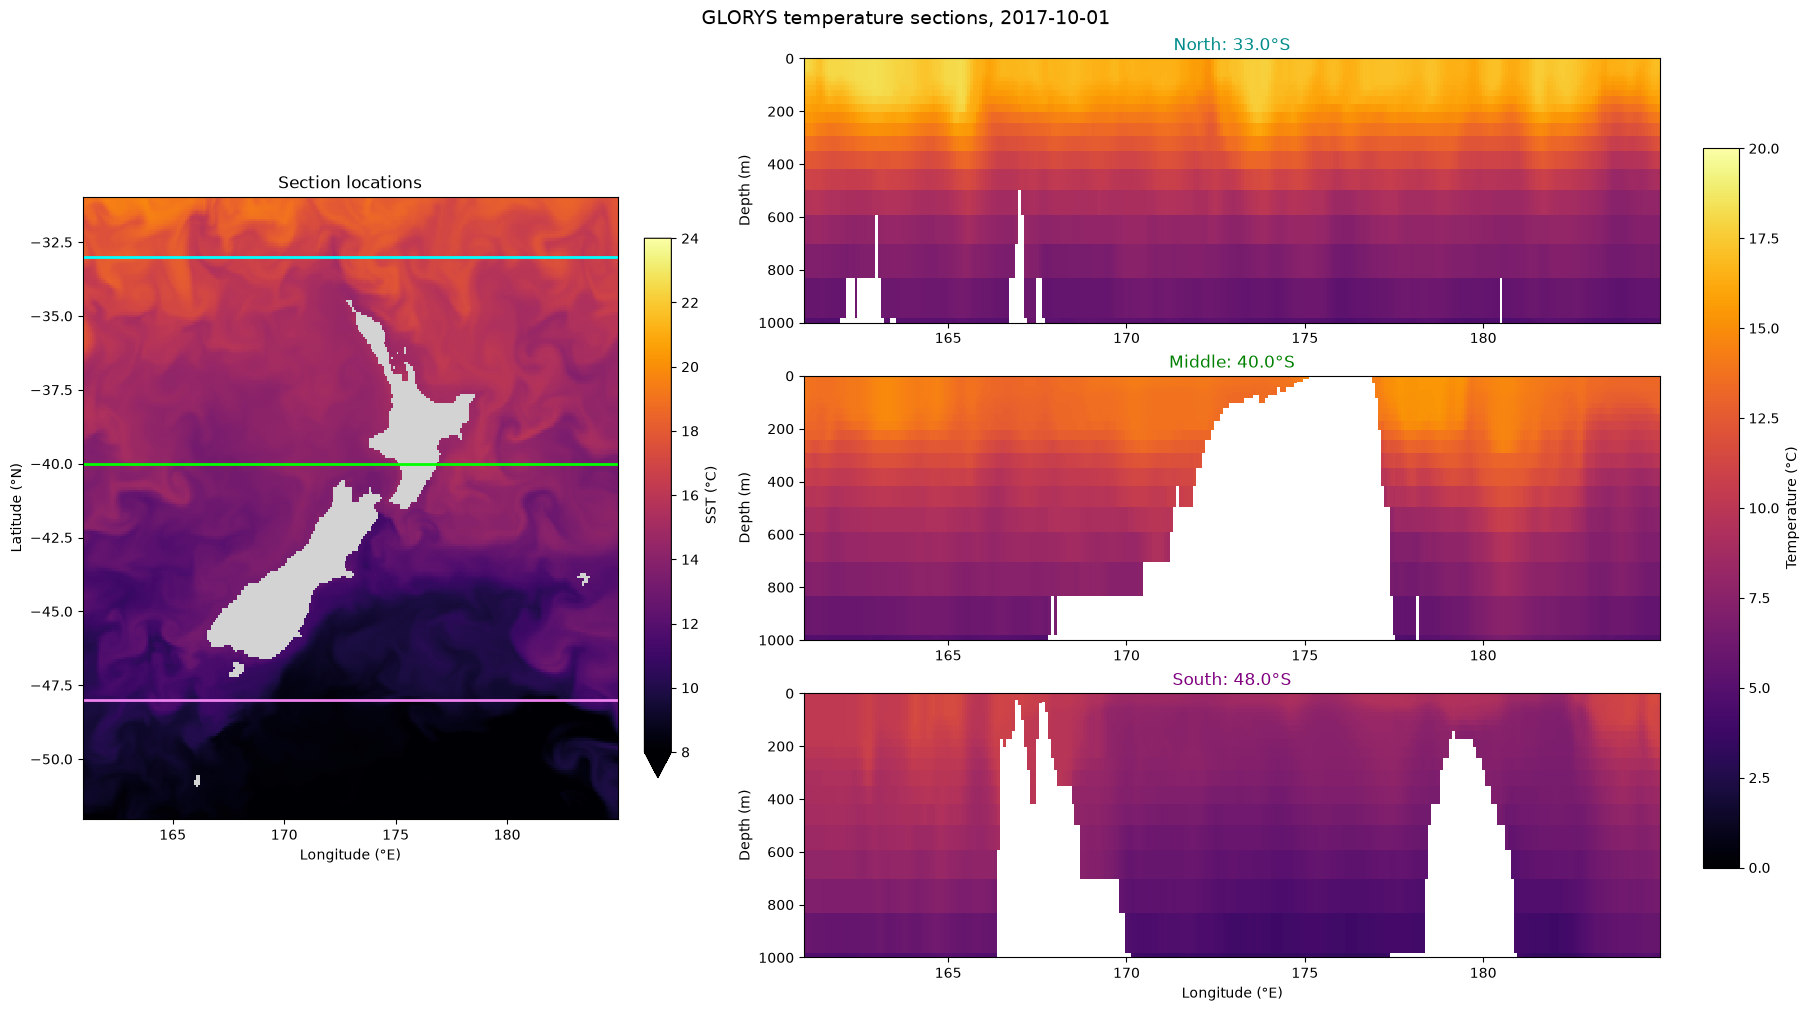

In [ ]:
# Plotting three lon sections to look at temperature variable

t = 0
sst = dataset["thetao"].isel(time=t, depth=0)
date = str(sst.time.values)[:10]

sec_n = dataset["thetao"].isel(time=t).sel(latitude=-33, method="nearest")   # north
sec_m = dataset["thetao"].isel(time=t).sel(latitude=-40, method="nearest")   # middle
sec_s = dataset["thetao"].isel(time=t).sel(latitude=-48, method="nearest")   # south

fig, axes = plt.subplot_mosaic([["map", "n"],
                                ["map", "m"],
                                ["map", "s"]],
                               figsize=(18, 10), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: map with the three section lines
sst.plot(ax=axes["map"], cmap="inferno", vmin=8, vmax=24,
         cbar_kwargs={"label": "SST (°C)", "shrink": 0.6})
axes["map"].axhline(float(sec_n.latitude), color="cyan",   linewidth=2)
axes["map"].axhline(float(sec_m.latitude), color="lime",   linewidth=2)
axes["map"].axhline(float(sec_s.latitude), color="violet", linewidth=2)
axes["map"].set_aspect(1 / np.cos(np.deg2rad(41)))
axes["map"].set_facecolor("lightgrey")
axes["map"].set_xlabel("Longitude (°E)")
axes["map"].set_ylabel("Latitude (°N)")
axes["map"].set_title("Section locations")

# right: three sections, same colour scale, no individual colourbars
sec_n.plot(ax=axes["n"], y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20, add_colorbar=False)
sec_m.plot(ax=axes["m"], y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20, add_colorbar=False)
im = sec_s.plot(ax=axes["s"], y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20, add_colorbar=False)

axes["n"].set_title(f"North: {abs(float(sec_n.latitude)):.1f}°S", color="darkcyan")
axes["m"].set_title(f"Middle: {abs(float(sec_m.latitude)):.1f}°S", color="green")
axes["s"].set_title(f"South: {abs(float(sec_s.latitude)):.1f}°S", color="purple")

for k in ["n", "m", "s"]:
    axes[k].set_ylim(1000, 0)
    axes[k].set_ylabel("Depth (m)")
    axes[k].set_xlabel("")
axes["s"].set_xlabel("Longitude (°E)")

fig.colorbar(im, ax=[axes["n"], axes["m"], axes["s"]], label="Temperature (°C)", shrink=0.8)
fig.suptitle(f"GLORYS temperature sections, {date}", fontsize=14)
plt.savefig("../Figures/glorys_temp_three_lat_sections_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

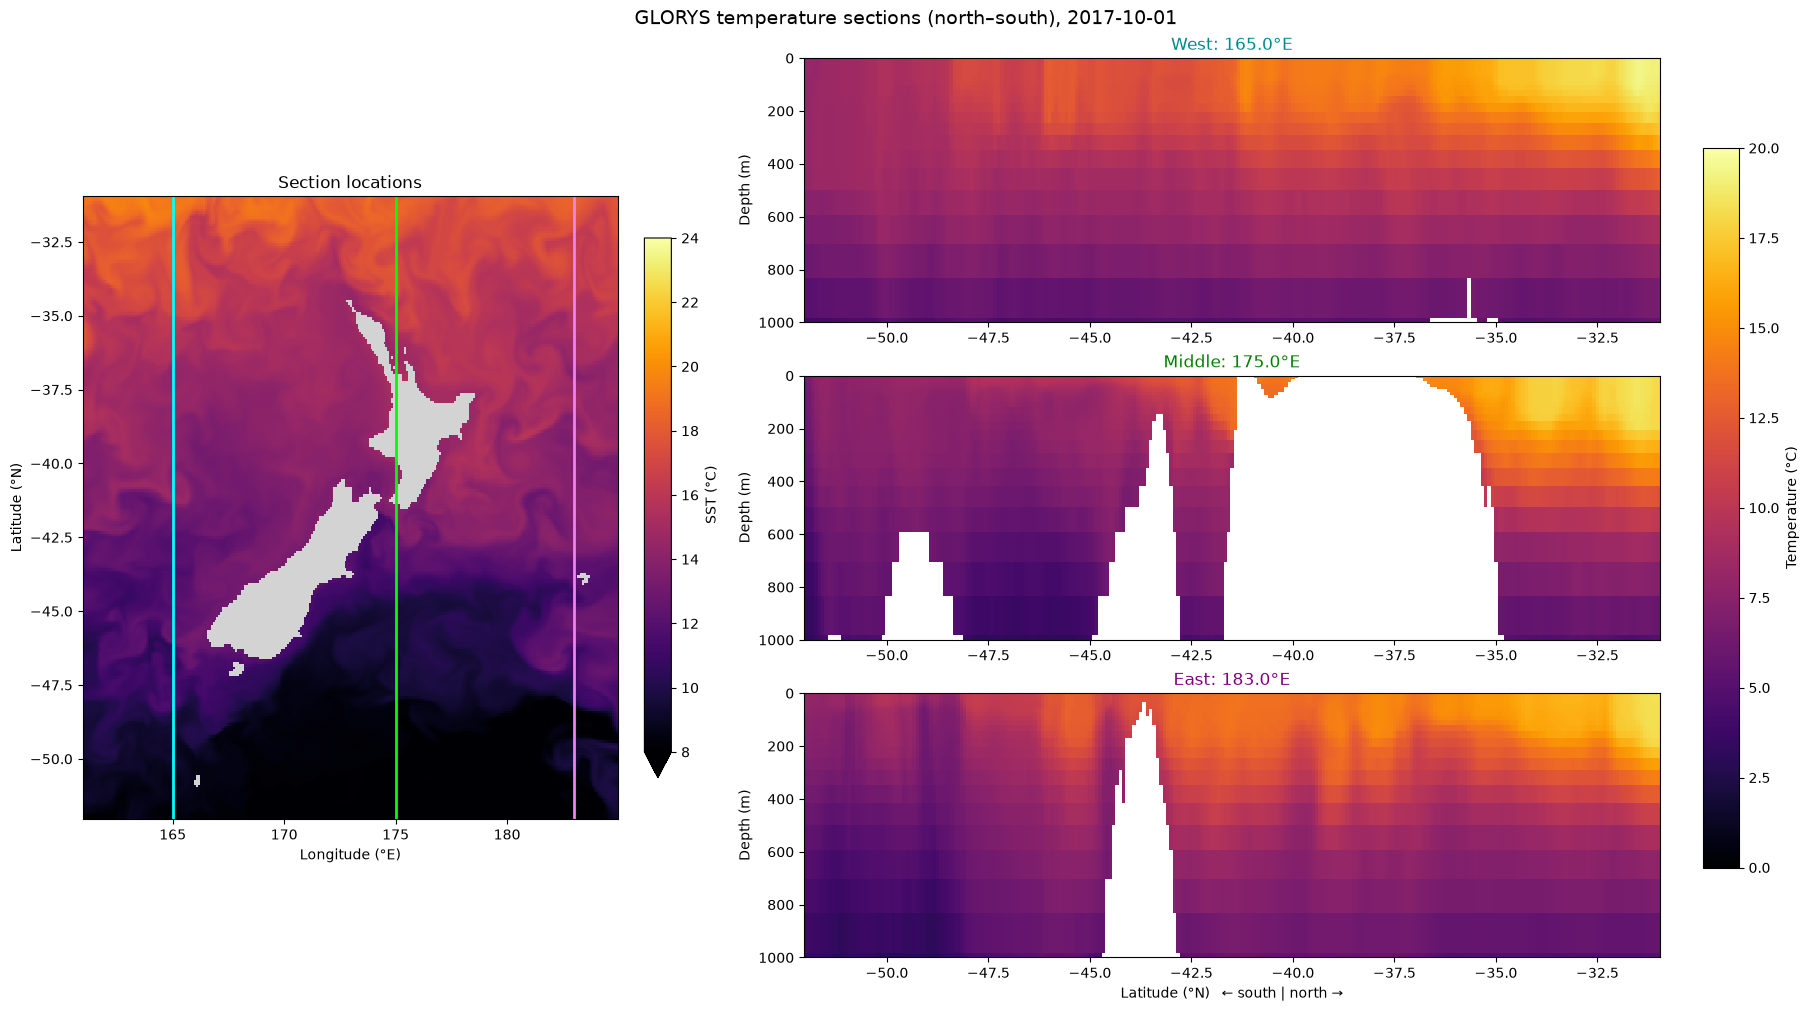

In [ ]:
# Plotting three lon sections to look at temperature 
t = 0
sst = dataset["thetao"].isel(time=t, depth=0)
date = str(sst.time.values)[:10]

sec_w = dataset["thetao"].isel(time=t).sel(longitude=165, method="nearest")   # west
sec_m = dataset["thetao"].isel(time=t).sel(longitude=175, method="nearest")   # middle
sec_e = dataset["thetao"].isel(time=t).sel(longitude=183, method="nearest")   # east

fig, axes = plt.subplot_mosaic([["map", "w"],
                                ["map", "m"],
                                ["map", "e"]],
                               figsize=(18, 10), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: map with the three section lines (vertical now)
sst.plot(ax=axes["map"], cmap="inferno", vmin=8, vmax=24,
         cbar_kwargs={"label": "SST (°C)", "shrink": 0.6})
axes["map"].axvline(float(sec_w.longitude), color="cyan",   linewidth=2)
axes["map"].axvline(float(sec_m.longitude), color="lime",   linewidth=2)
axes["map"].axvline(float(sec_e.longitude), color="violet", linewidth=2)
axes["map"].set_aspect(1 / np.cos(np.deg2rad(41)))
axes["map"].set_facecolor("lightgrey")
axes["map"].set_xlabel("Longitude (°E)")
axes["map"].set_ylabel("Latitude (°N)")
axes["map"].set_title("Section locations")

# right: three sections, latitude on the x-axis
sec_w.plot(ax=axes["w"], y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20, add_colorbar=False)
sec_m.plot(ax=axes["m"], y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20, add_colorbar=False)
im = sec_e.plot(ax=axes["e"], y="depth", yincrease=False, cmap="inferno", vmin=0, vmax=20, add_colorbar=False)

axes["w"].set_title(f"West: {float(sec_w.longitude):.1f}°E", color="darkcyan")
axes["m"].set_title(f"Middle: {float(sec_m.longitude):.1f}°E", color="green")
axes["e"].set_title(f"East: {float(sec_e.longitude):.1f}°E", color="purple")

for k in ["w", "m", "e"]:
    axes[k].set_ylim(1000, 0)
    axes[k].set_ylabel("Depth (m)")
    axes[k].set_xlabel("")
axes["e"].set_xlabel("Latitude (°N)   ← south | north →")

fig.colorbar(im, ax=[axes["w"], axes["m"], axes["e"]], label="Temperature (°C)", shrink=0.8)
fig.suptitle(f"GLORYS temperature sections (north–south), {date}", fontsize=14)
plt.savefig("../Figures/glorys_temp_three_lon_sections_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

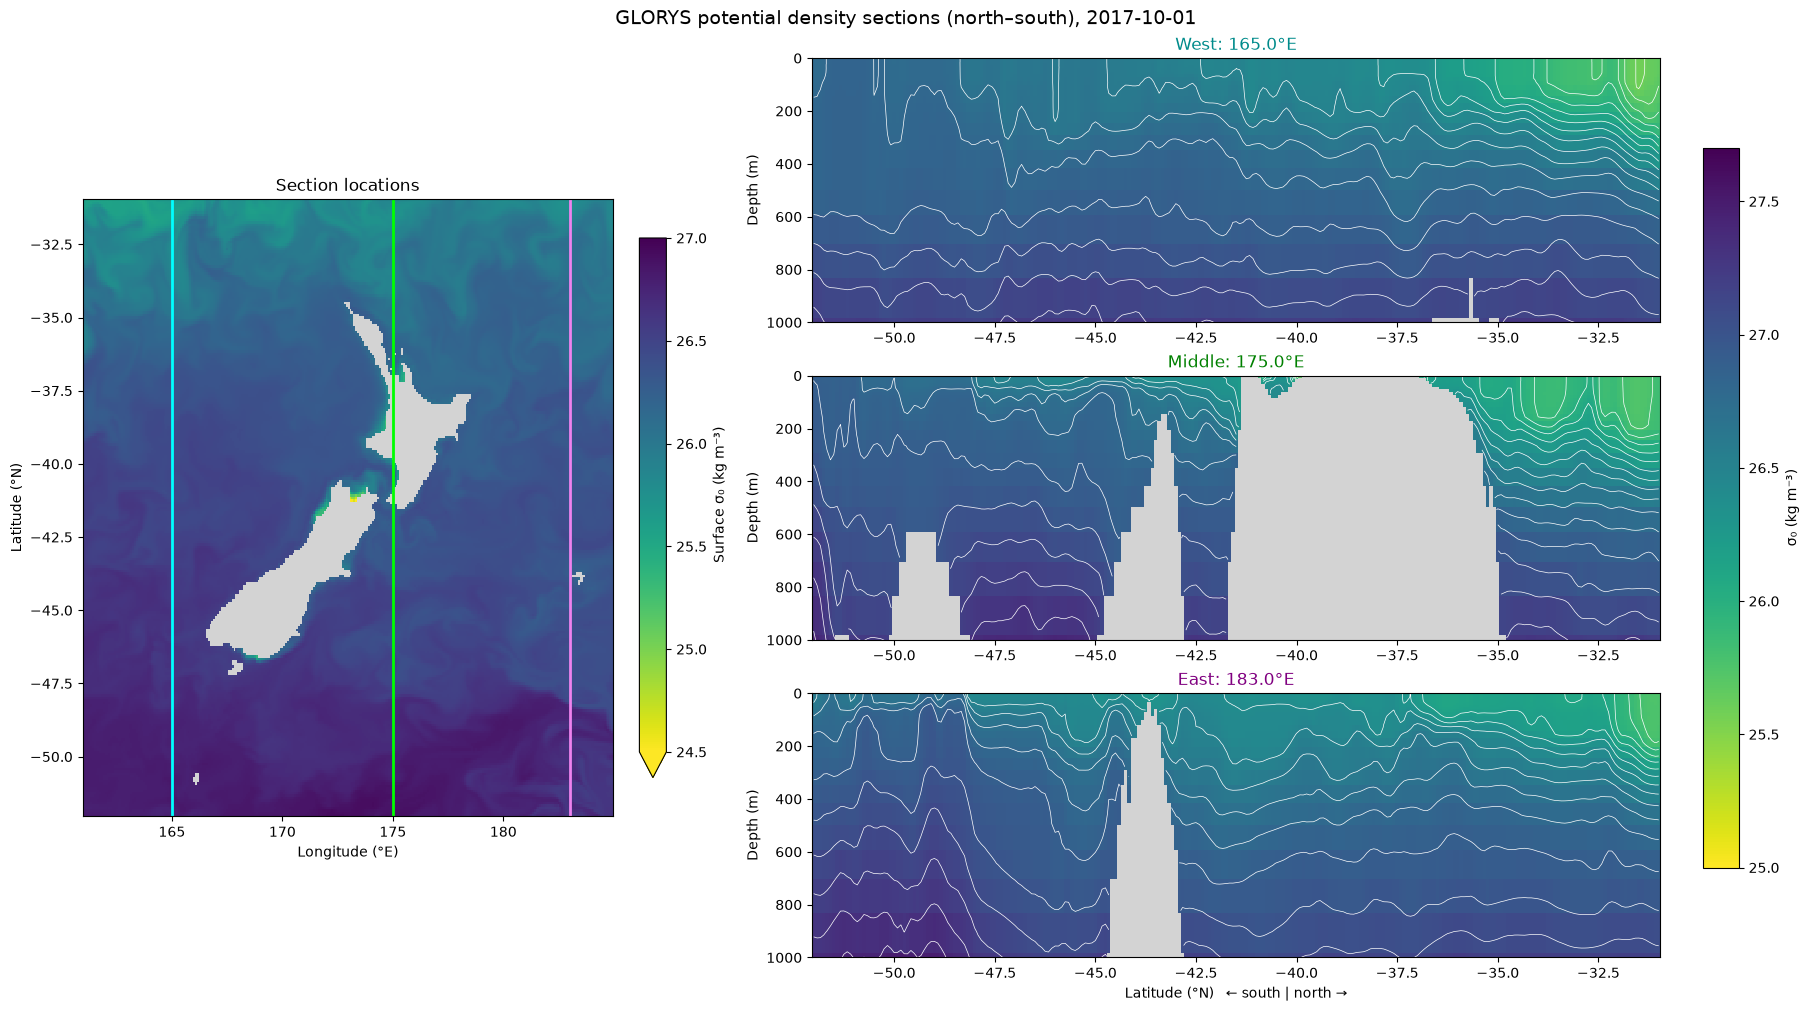

In [ ]:
# Plotting three lon sections to look at potential density 
# --- 1) potential density for the whole day (3D) ---
day = dataset.isel(time=0)
date = str(day.time.values)[:10]
depth = day.depth.values[:, None, None]
lat   = day.latitude.values[None, :, None]
lon   = day.longitude.values[None, None, :]

p  = gsw.p_from_z(-depth, lat)                        # pressure (dbar)
SA = gsw.SA_from_SP(day["so"].values, p, lon, lat)    # absolute salinity
CT = gsw.CT_from_pt(SA, day["thetao"].values)         # conservative temperature
sigma0 = xr.DataArray(gsw.sigma0(SA, CT), coords=day["so"].coords, dims=day["so"].dims)

# --- 2) surface map and three north–south sections ---
surf  = sigma0.isel(depth=0)
sec_w = sigma0.sel(longitude=165, method="nearest")
sec_m = sigma0.sel(longitude=175, method="nearest")
sec_e = sigma0.sel(longitude=183, method="nearest")

levels = np.arange(25.0, 27.8, 0.1)                   # contour every 0.1 kg/m³
cmap = "viridis_r"                                    # dark = dense (deep)

fig, axes = plt.subplot_mosaic([["map", "w"],
                                ["map", "m"],
                                ["map", "e"]],
                               figsize=(18, 10), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: surface density map with the section lines
surf.plot(ax=axes["map"], cmap=cmap, vmin=24.5, vmax=27,
          cbar_kwargs={"label": "Surface σ₀ (kg m⁻³)", "shrink": 0.6})
axes["map"].axvline(float(sec_w.longitude), color="cyan",   linewidth=2)
axes["map"].axvline(float(sec_m.longitude), color="lime",   linewidth=2)
axes["map"].axvline(float(sec_e.longitude), color="violet", linewidth=2)
axes["map"].set_aspect(1 / np.cos(np.deg2rad(41)))
axes["map"].set_facecolor("lightgrey")
axes["map"].set_xlabel("Longitude (°E)")
axes["map"].set_ylabel("Latitude (°N)")
axes["map"].set_title("Section locations")

# right: density sections with contour lines
sec_w.plot(ax=axes["w"], y="depth", yincrease=False, cmap=cmap, vmin=25, vmax=27.7, add_colorbar=False)
sec_m.plot(ax=axes["m"], y="depth", yincrease=False, cmap=cmap, vmin=25, vmax=27.7, add_colorbar=False)
im = sec_e.plot(ax=axes["e"], y="depth", yincrease=False, cmap=cmap, vmin=25, vmax=27.7, add_colorbar=False)

sec_w.plot.contour(ax=axes["w"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_m.plot.contour(ax=axes["m"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_e.plot.contour(ax=axes["e"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)

axes["w"].set_title(f"West: {float(sec_w.longitude):.1f}°E", color="darkcyan")
axes["m"].set_title(f"Middle: {float(sec_m.longitude):.1f}°E", color="green")
axes["e"].set_title(f"East: {float(sec_e.longitude):.1f}°E", color="purple")

for k in ["w", "m", "e"]:
    axes[k].set_ylim(1000, 0)
    axes[k].set_ylabel("Depth (m)")
    axes[k].set_xlabel("")
    axes[k].set_facecolor("lightgrey")      # seafloor/land in grey
axes["e"].set_xlabel("Latitude (°N)   ← south | north →")

fig.colorbar(im, ax=[axes["w"], axes["m"], axes["e"]], label="σ₀ (kg m⁻³)", shrink=0.8)
fig.suptitle(f"GLORYS potential density sections (north–south), {date}", fontsize=14)
plt.savefig("../Figures/glorys_sigma0_lon_sections_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

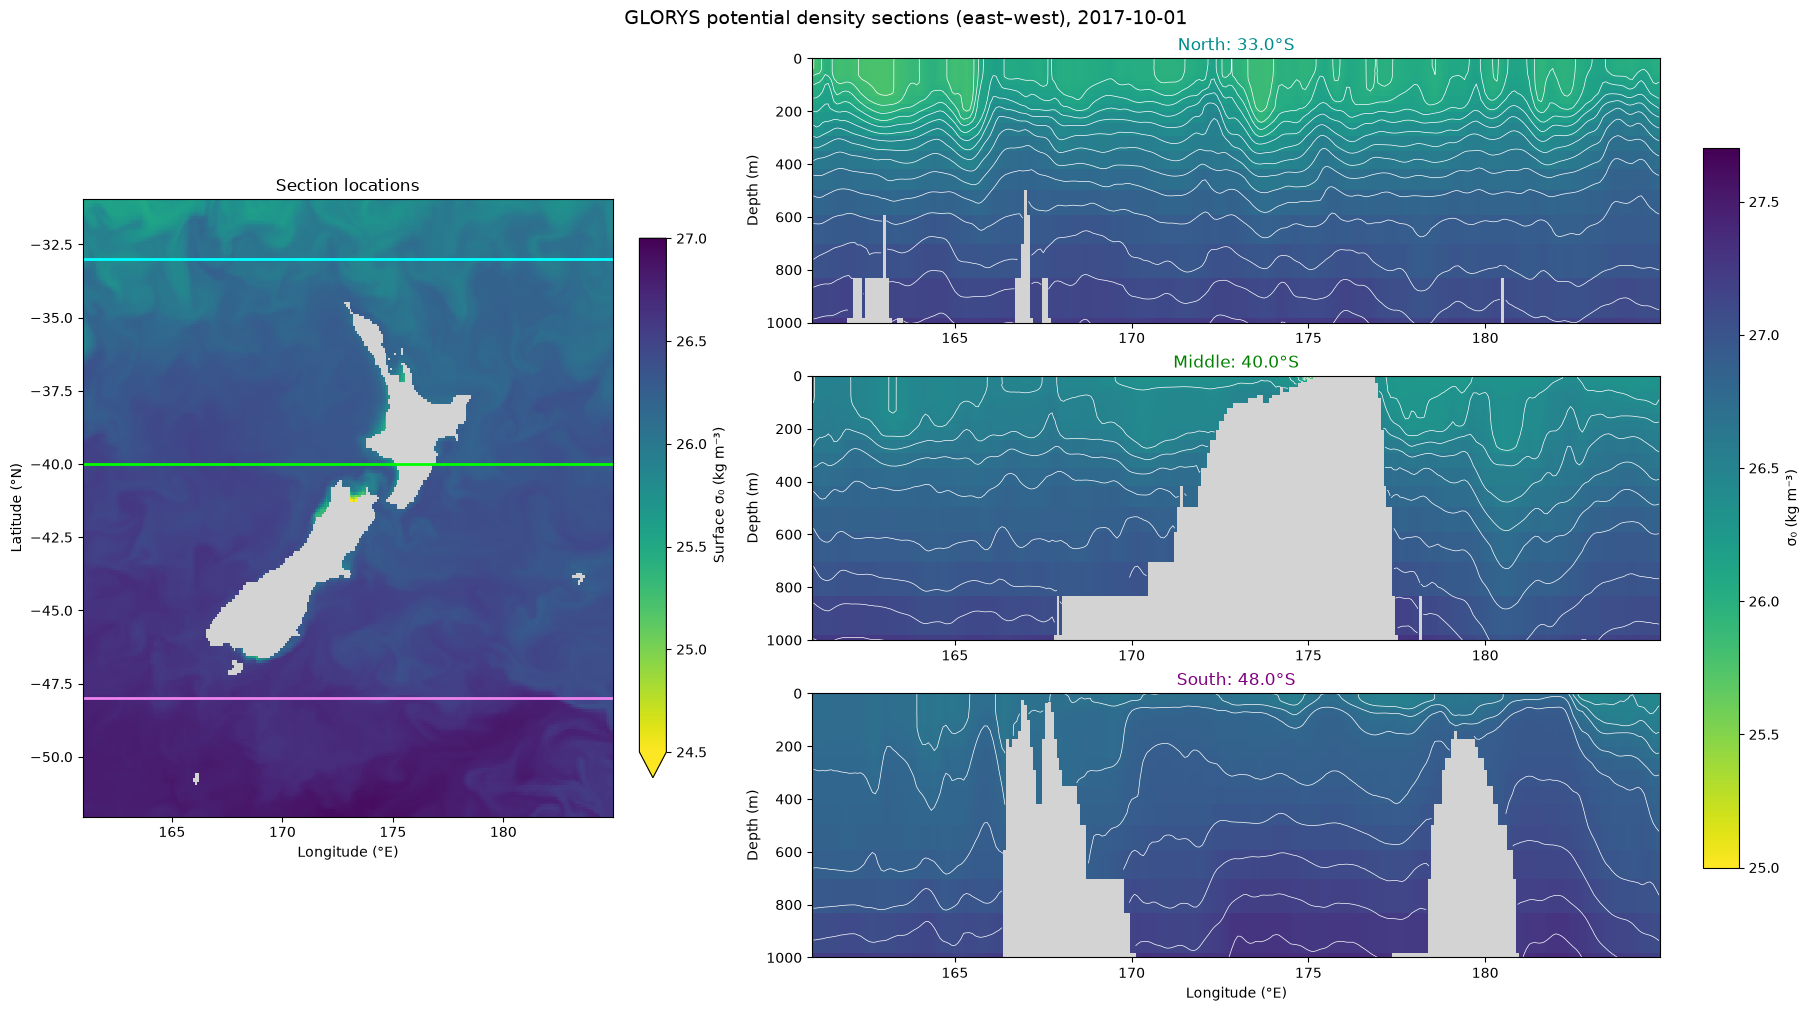

In [ ]:
# Plotting three lat sections to look at potential density 

surf  = sigma0.isel(depth=0)
sec_n = sigma0.sel(latitude=-33, method="nearest")   # north
sec_m = sigma0.sel(latitude=-40, method="nearest")   # middle
sec_s = sigma0.sel(latitude=-48, method="nearest")   # south

levels = np.arange(25.0, 27.8, 0.1)
cmap = "viridis_r"                                   # dark = dense (deep)

fig, axes = plt.subplot_mosaic([["map", "n"],
                                ["map", "m"],
                                ["map", "s"]],
                               figsize=(18, 10), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: surface density map with the section lines (horizontal)
surf.plot(ax=axes["map"], cmap=cmap, vmin=24.5, vmax=27,
          cbar_kwargs={"label": "Surface σ₀ (kg m⁻³)", "shrink": 0.6})
axes["map"].axhline(float(sec_n.latitude), color="cyan",   linewidth=2)
axes["map"].axhline(float(sec_m.latitude), color="lime",   linewidth=2)
axes["map"].axhline(float(sec_s.latitude), color="violet", linewidth=2)
axes["map"].set_aspect(1 / np.cos(np.deg2rad(41)))
axes["map"].set_facecolor("lightgrey")
axes["map"].set_xlabel("Longitude (°E)")
axes["map"].set_ylabel("Latitude (°N)")
axes["map"].set_title("Section locations")

# right: density sections with contour lines
sec_n.plot(ax=axes["n"], y="depth", yincrease=False, cmap=cmap, vmin=25, vmax=27.7, add_colorbar=False)
sec_m.plot(ax=axes["m"], y="depth", yincrease=False, cmap=cmap, vmin=25, vmax=27.7, add_colorbar=False)
im = sec_s.plot(ax=axes["s"], y="depth", yincrease=False, cmap=cmap, vmin=25, vmax=27.7, add_colorbar=False)

sec_n.plot.contour(ax=axes["n"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_m.plot.contour(ax=axes["m"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_s.plot.contour(ax=axes["s"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)

axes["n"].set_title(f"North: {abs(float(sec_n.latitude)):.1f}°S", color="darkcyan")
axes["m"].set_title(f"Middle: {abs(float(sec_m.latitude)):.1f}°S", color="green")
axes["s"].set_title(f"South: {abs(float(sec_s.latitude)):.1f}°S", color="purple")

for k in ["n", "m", "s"]:
    axes[k].set_ylim(1000, 0)
    axes[k].set_ylabel("Depth (m)")
    axes[k].set_xlabel("")
    axes[k].set_facecolor("lightgrey")
axes["s"].set_xlabel("Longitude (°E)")

fig.colorbar(im, ax=[axes["n"], axes["m"], axes["s"]], label="σ₀ (kg m⁻³)", shrink=0.8)
fig.suptitle(f"GLORYS potential density sections (east–west), {date}", fontsize=14)
plt.savefig("../Figures/glorys_sigma0_lat_sections_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

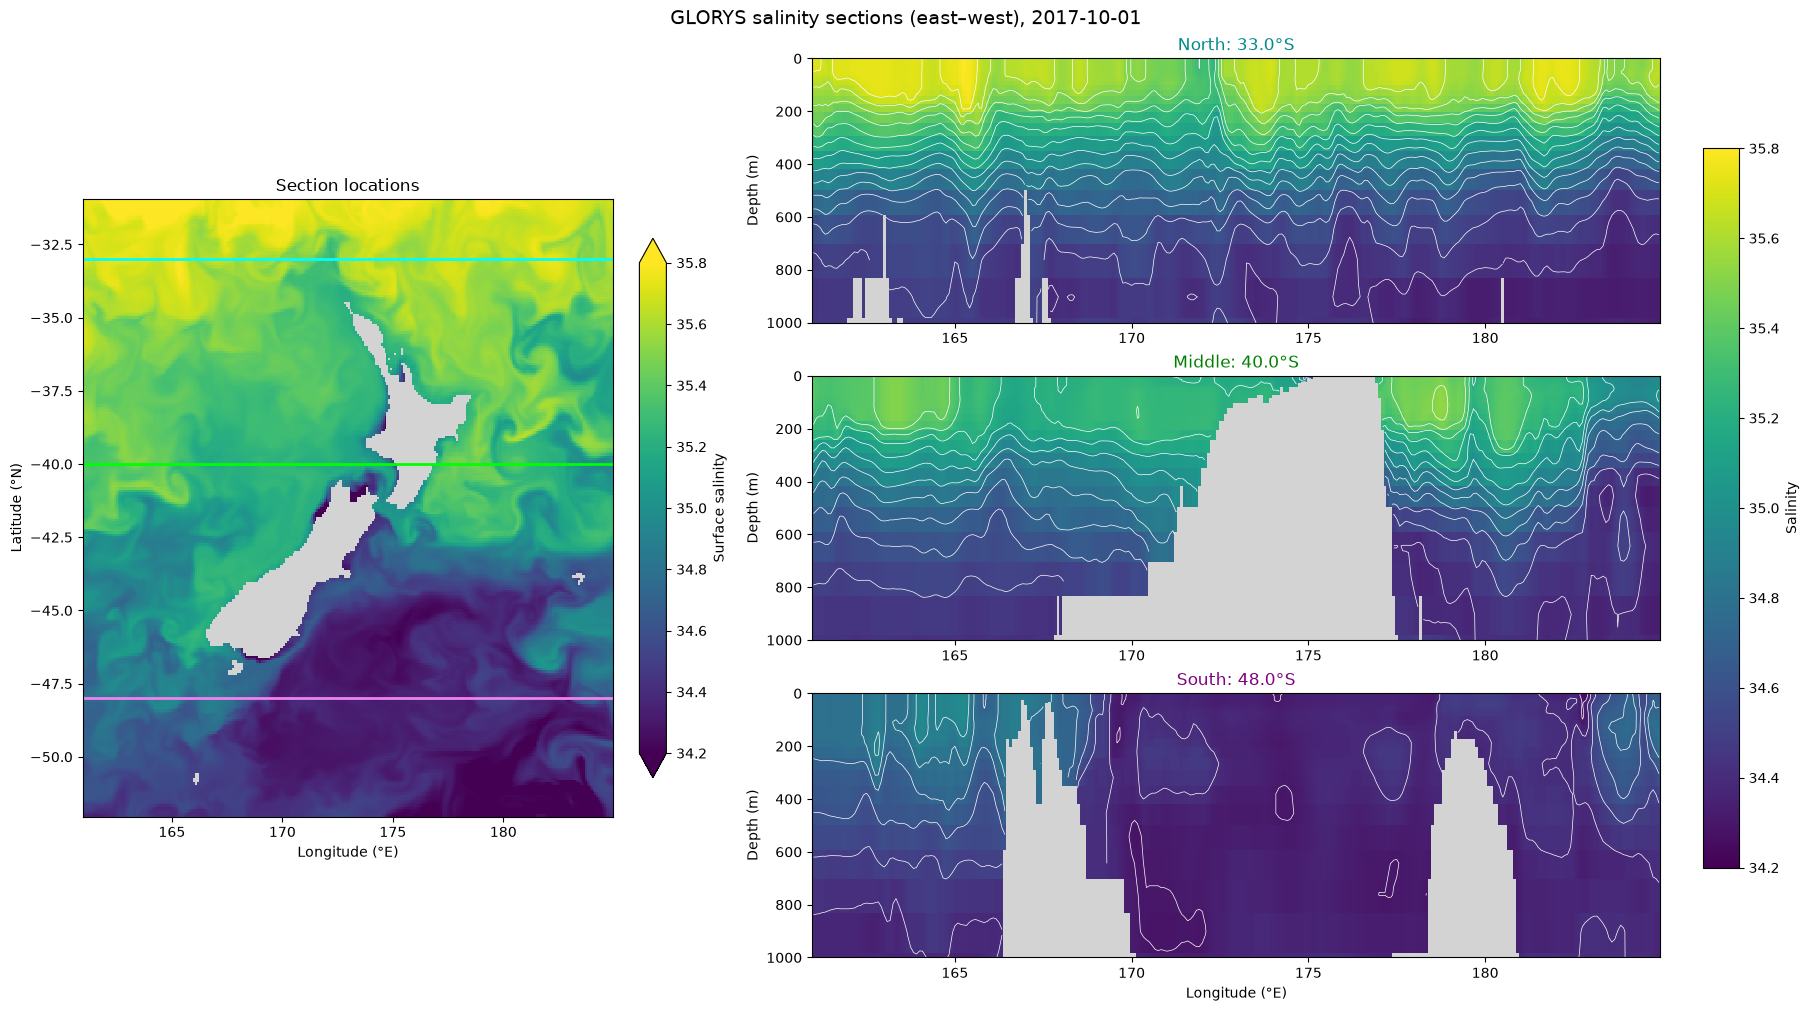

In [ ]:
# Plotting three lat section to look at salinity 
so = dataset["so"].isel(time=0)
date = str(so.time.values)[:10]

surf  = so.isel(depth=0)
sec_n = so.sel(latitude=-33, method="nearest")   # north
sec_m = so.sel(latitude=-40, method="nearest")   # middle
sec_s = so.sel(latitude=-48, method="nearest")   # south

levels = np.arange(34.0, 36.0, 0.1)              # contour every 0.1
cmap = "viridis"
vmin, vmax = 34.2, 35.8                          # same range for map and sections

fig, axes = plt.subplot_mosaic([["map", "n"],
                                ["map", "m"],
                                ["map", "s"]],
                               figsize=(18, 10), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: surface salinity map with the section lines
surf.plot(ax=axes["map"], cmap=cmap, vmin=vmin, vmax=vmax,
          cbar_kwargs={"label": "Surface salinity", "shrink": 0.6})
axes["map"].axhline(float(sec_n.latitude), color="cyan",   linewidth=2)
axes["map"].axhline(float(sec_m.latitude), color="lime",   linewidth=2)
axes["map"].axhline(float(sec_s.latitude), color="violet", linewidth=2)
axes["map"].set_aspect(1 / np.cos(np.deg2rad(41)))
axes["map"].set_facecolor("lightgrey")
axes["map"].set_xlabel("Longitude (°E)")
axes["map"].set_ylabel("Latitude (°N)")
axes["map"].set_title("Section locations")

# right: salinity sections with contour lines
sec_n.plot(ax=axes["n"], y="depth", yincrease=False, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
sec_m.plot(ax=axes["m"], y="depth", yincrease=False, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
im = sec_s.plot(ax=axes["s"], y="depth", yincrease=False, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)

sec_n.plot.contour(ax=axes["n"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_m.plot.contour(ax=axes["m"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_s.plot.contour(ax=axes["s"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)

axes["n"].set_title(f"North: {abs(float(sec_n.latitude)):.1f}°S", color="darkcyan")
axes["m"].set_title(f"Middle: {abs(float(sec_m.latitude)):.1f}°S", color="green")
axes["s"].set_title(f"South: {abs(float(sec_s.latitude)):.1f}°S", color="purple")

for k in ["n", "m", "s"]:
    axes[k].set_ylim(1000, 0)
    axes[k].set_ylabel("Depth (m)")
    axes[k].set_xlabel("")
    axes[k].set_facecolor("lightgrey")
axes["s"].set_xlabel("Longitude (°E)")

fig.colorbar(im, ax=[axes["n"], axes["m"], axes["s"]], label="Salinity", shrink=0.8)
fig.suptitle(f"GLORYS salinity sections (east–west), {date}", fontsize=14)
plt.savefig("../Figures/glorys_salinity_lat_sections_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()

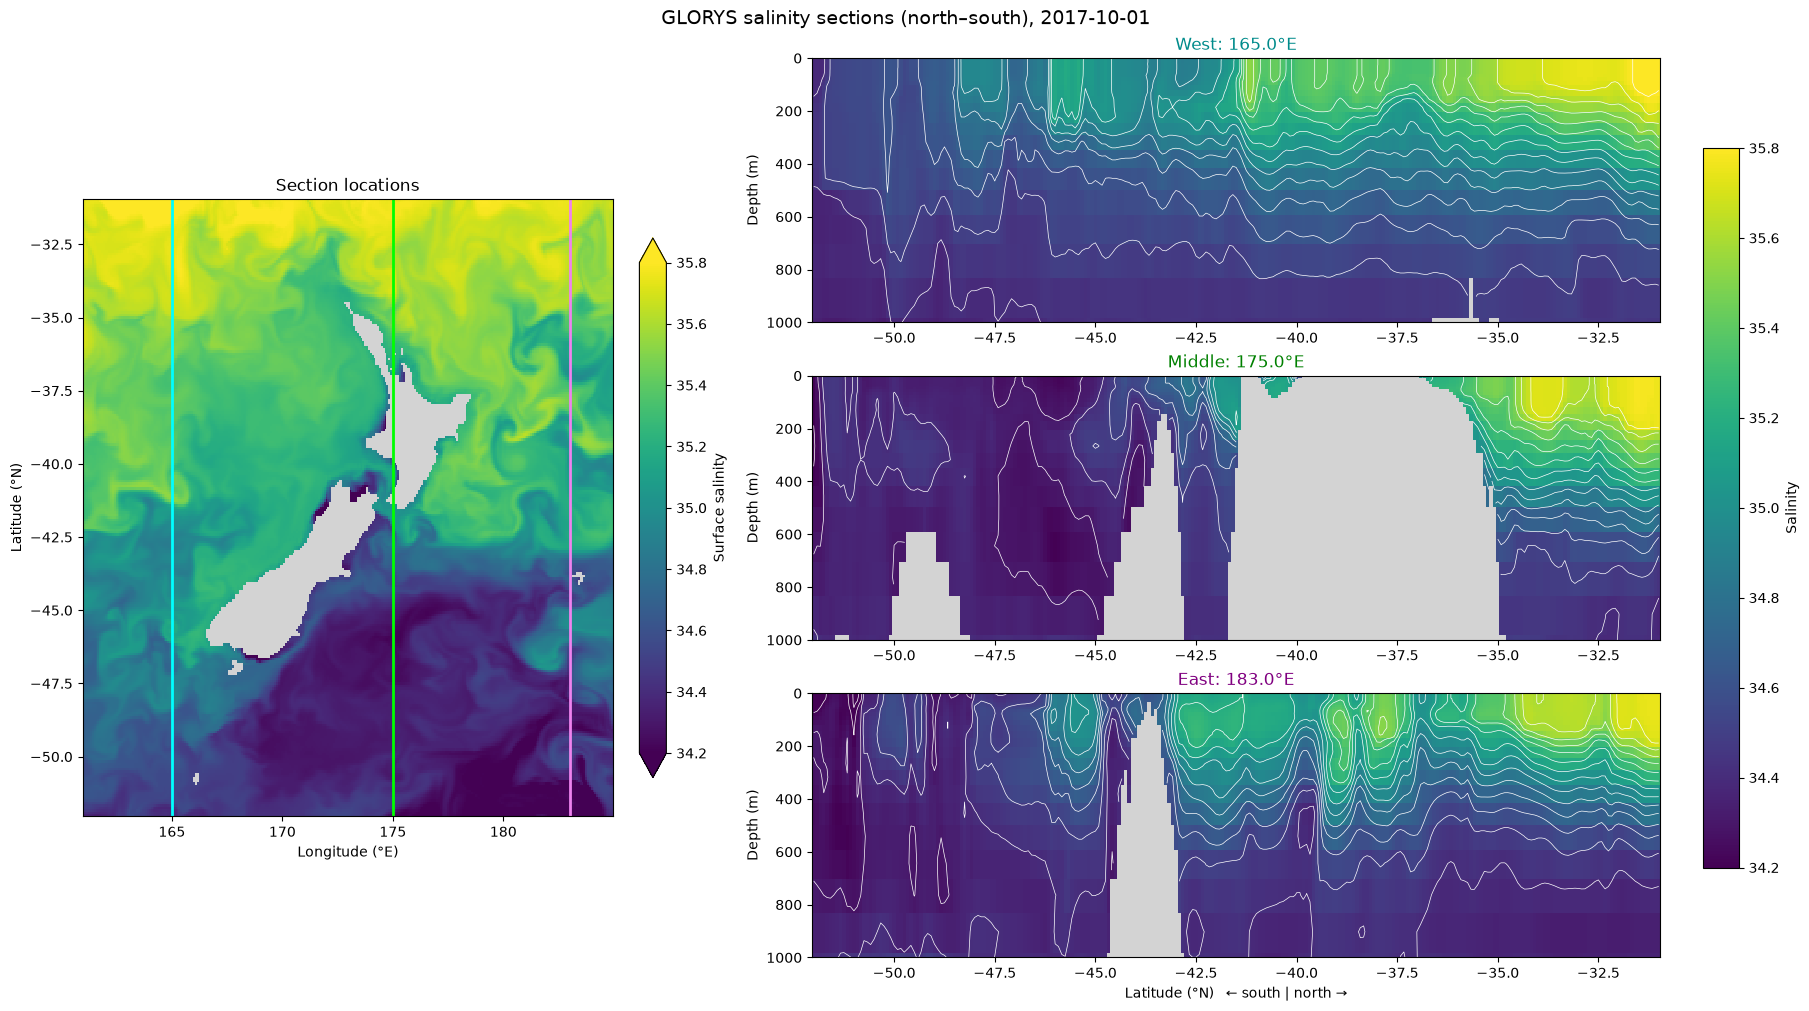

In [ ]:
# Plotting three lon sections to look at salinity 
so = dataset["so"].isel(time=0)
date = str(so.time.values)[:10]

surf  = so.isel(depth=0)
sec_w = so.sel(longitude=165, method="nearest")   # west
sec_m = so.sel(longitude=175, method="nearest")   # middle
sec_e = so.sel(longitude=183, method="nearest")   # east

levels = np.arange(34.0, 36.0, 0.1)
cmap = "viridis"
vmin, vmax = 34.2, 35.8

fig, axes = plt.subplot_mosaic([["map", "w"],
                                ["map", "m"],
                                ["map", "e"]],
                               figsize=(18, 10), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 1.6]})

# left: surface salinity map with the section lines (vertical)
surf.plot(ax=axes["map"], cmap=cmap, vmin=vmin, vmax=vmax,
          cbar_kwargs={"label": "Surface salinity", "shrink": 0.6})
axes["map"].axvline(float(sec_w.longitude), color="cyan",   linewidth=2)
axes["map"].axvline(float(sec_m.longitude), color="lime",   linewidth=2)
axes["map"].axvline(float(sec_e.longitude), color="violet", linewidth=2)
axes["map"].set_aspect(1 / np.cos(np.deg2rad(41)))
axes["map"].set_facecolor("lightgrey")
axes["map"].set_xlabel("Longitude (°E)")
axes["map"].set_ylabel("Latitude (°N)")
axes["map"].set_title("Section locations")

# right: salinity sections with contour lines
sec_w.plot(ax=axes["w"], y="depth", yincrease=False, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
sec_m.plot(ax=axes["m"], y="depth", yincrease=False, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
im = sec_e.plot(ax=axes["e"], y="depth", yincrease=False, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)

sec_w.plot.contour(ax=axes["w"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_m.plot.contour(ax=axes["m"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)
sec_e.plot.contour(ax=axes["e"], y="depth", yincrease=False, levels=levels, colors="white", linewidths=0.5)

axes["w"].set_title(f"West: {float(sec_w.longitude):.1f}°E", color="darkcyan")
axes["m"].set_title(f"Middle: {float(sec_m.longitude):.1f}°E", color="green")
axes["e"].set_title(f"East: {float(sec_e.longitude):.1f}°E", color="purple")

for k in ["w", "m", "e"]:
    axes[k].set_ylim(1000, 0)
    axes[k].set_ylabel("Depth (m)")
    axes[k].set_xlabel("")
    axes[k].set_facecolor("lightgrey")
axes["e"].set_xlabel("Latitude (°N)   ← south | north →")

fig.colorbar(im, ax=[axes["w"], axes["m"], axes["e"]], label="Salinity", shrink=0.8)
fig.suptitle(f"GLORYS salinity sections (north–south), {date}", fontsize=14)
plt.savefig("../Figures/glorys_salinity_lon_sections_Oct17.png", dpi=200, bbox_inches="tight")
plt.show()